In [1]:
import hoda
import tensorly as tl
import mne

mne.set_log_level('ERROR')
tl.get_backend()

'cupy'

In [2]:
from moabb.paradigms import P300, MotorImagery
from moabb.datasets import *
from mne.decoding import Scaler


paradigm = P300(resample=128)
dataset = BNCI2014009()

"""
tmin = -0.2
tmax=None
fmin = 8
fmax = 30
sfreq = 60
paradigm = MotorImagery(resample=sfreq, tmin=tmin, tmax=tmax, fmin=fmin, fmax=fmax,  n_classes=4)
dataset=  BNCI2014_001()
"""


epochs, labels, meta = paradigm.get_data(
    dataset=dataset, 
     subjects=[1],
     return_epochs=True
)
session = meta['session'][0]
idc = meta['session'] == session
epochs = epochs[idc]
labels = labels[idc]
meta = meta[idc]


epochs._data = Scaler(scalings='mean', with_mean=True).fit_transform(epochs._data)

BNCI2014009 has been renamed to BNCI2014_009. BNCI2014009 will be removed in version 1.1.
The dataset class name 'BNCI2014009' must be an abbreviation of its code 'BNCI2014-009'. See moabb.datasets.base.is_abbrev for more information.


To use the get_shape_from_baseconcar, InputShapeSetterEEG, BraindecodeDatasetLoaderyou need to install `braindecode`.`pip install braindecode` or Please refer to `https://braindecode.org`.


In [3]:
meta

,subject,session,run
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,1,0,0
...,...,...,...
571,1,0,0
572,1,0,0
573,1,0,0
574,1,0,0


In [4]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl
from hoda.tensorize import STFTensor
import numpy as np

nfreqs=16

X = epochs.get_data()
"""
tensor =  STFTensor(sfreq=sfreq, tmin=tmin,
            morlet_params=dict(freqs=np.linspace(fmin, fmax, nfreqs)),
            baseline_params=dict(baseline=(-.15,-.05), mode='logratio'),
            decim=8
)

X = tensor.fit_transform(X)
"""
y = labels

X.shape

(576, 16, 103)

In [5]:
from hoda.hoda import BTTDA, HODA, trunc_eigh
from hoda.cov import mode_scatter


bttda = BTTDA(
    ranks=[4]*16,
    hoda_params=dict(
        max_iter=256,
        tol=1e-16,
        init ='random',
        shrinkage='lw',
        toeplitz=None,
        obj='rt',
        solver='lanczos',
        taper=True,
        extra_train_info=False,
        verbose=True,
        delta=None,
        ortho=False,
        fit_forward=True,
        random_state=42,
       
    ),
    verbose=True,
    extra_train_info=True,
)
#%env PYTHONWARNINGS=ignore
bttda.fit(X,y)

Fitting block 1/16...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 2/16...


/usr/local/lib/python3.10/dist-packages/cupy/linalg/_solve.py:169: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


...

  0%|          | 0/256 [00:00<?, ?it/s]

Fitting block 16/16...


  0%|          | 0/256 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

BTTDA(extra_train_info=True,
      hoda_params={'delta': None, 'extra_train_info': False,
                   'fit_forward': True, 'init': 'random', 'max_iter': 256,
                   'obj': 'rt', 'ortho': False, 'random_state': 42, 'rank': 4,
                   'shrinkage': 'lw', 'solver': 'lanczos', 'taper': True,
                   'toeplitz': None, 'tol': 1e-12, 'verbose': True},
      ranks=[4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4], verbose=True)

In [6]:
import pandas as pd
df = pd.DataFrame(bttda.train_info_)
df

,block,rank,F_tr,F_rt,mse
0,1,"(4, 4)",0.213327,0.010890,0.894052
1,2,"(4, 4)",0.177512,0.012647,0.852037
2,3,"(4, 4)",0.156996,0.014048,0.819137
3,4,"(4, 4)",0.150232,0.014392,0.798142
4,5,"(4, 4)",0.143045,0.015271,0.768926
5,6,"(4, 4)",0.136767,0.015944,0.755995
6,7,"(4, 4)",0.133004,0.016285,0.732103
7,8,"(4, 4)",0.130481,0.016589,0.722284
8,9,"(4, 4)",0.127934,0.016800,0.715167
9,10,"(4, 4)",0.125462,0.017188,0.700228


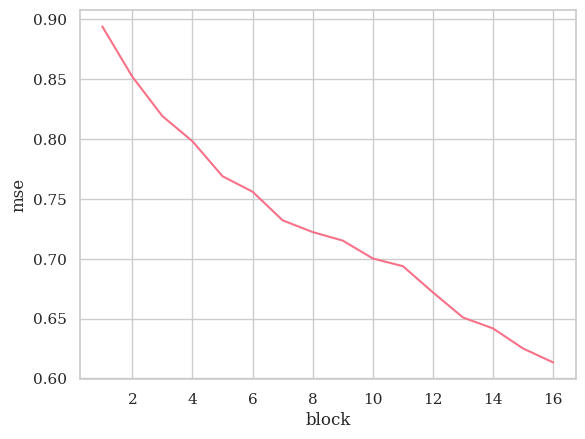

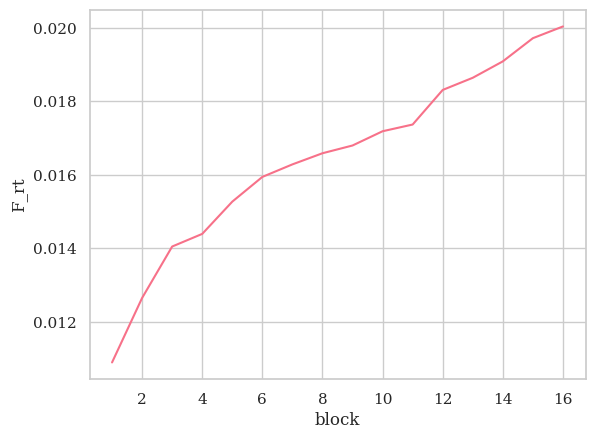

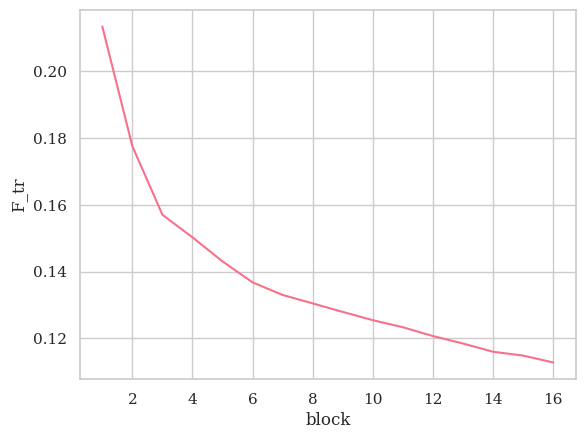

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

if bttda.extra_train_info:
    n_samples = X.shape[0]
    sns.lineplot(data=df, x='block', y='mse')
    plt.show()
    sns.lineplot(data=df,x='block',y='F_rt')
    plt.show()
    sns.lineplot(data=df,x='block',y='F_tr')

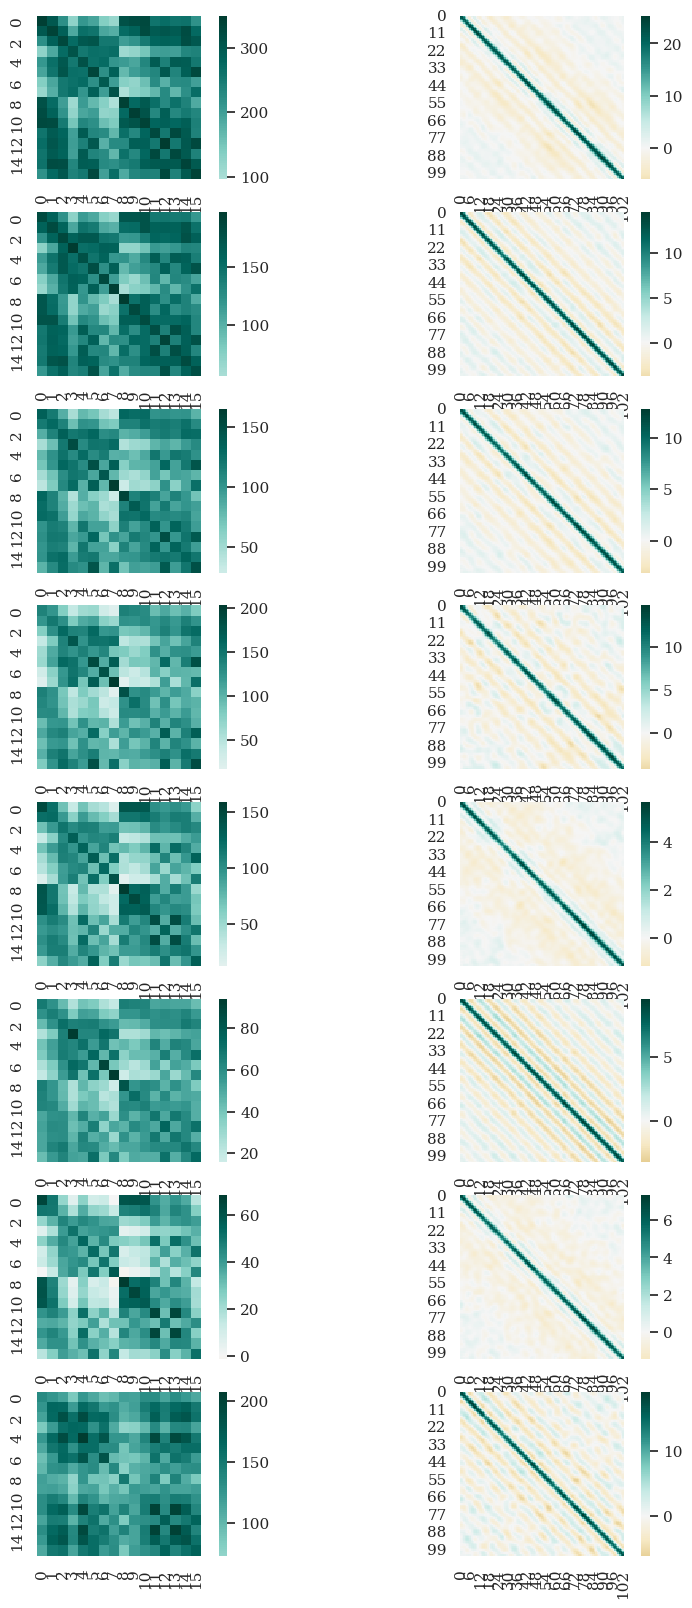

In [8]:
fig, axs = plt.subplots(min(bttda.n_blocks_,8),2, figsize=(10,20))
for b in range(min(bttda.n_blocks_,8)):
    for k in range(2):
        scatter = bttda.blocks_[b].scatter_w_[k]
        scatter = tl.to_numpy(scatter)
        sns.heatmap(scatter, ax=axs[b,k], square=True, center=0, cmap='BrBG')

In [9]:
Xt = bttda.transform(X)

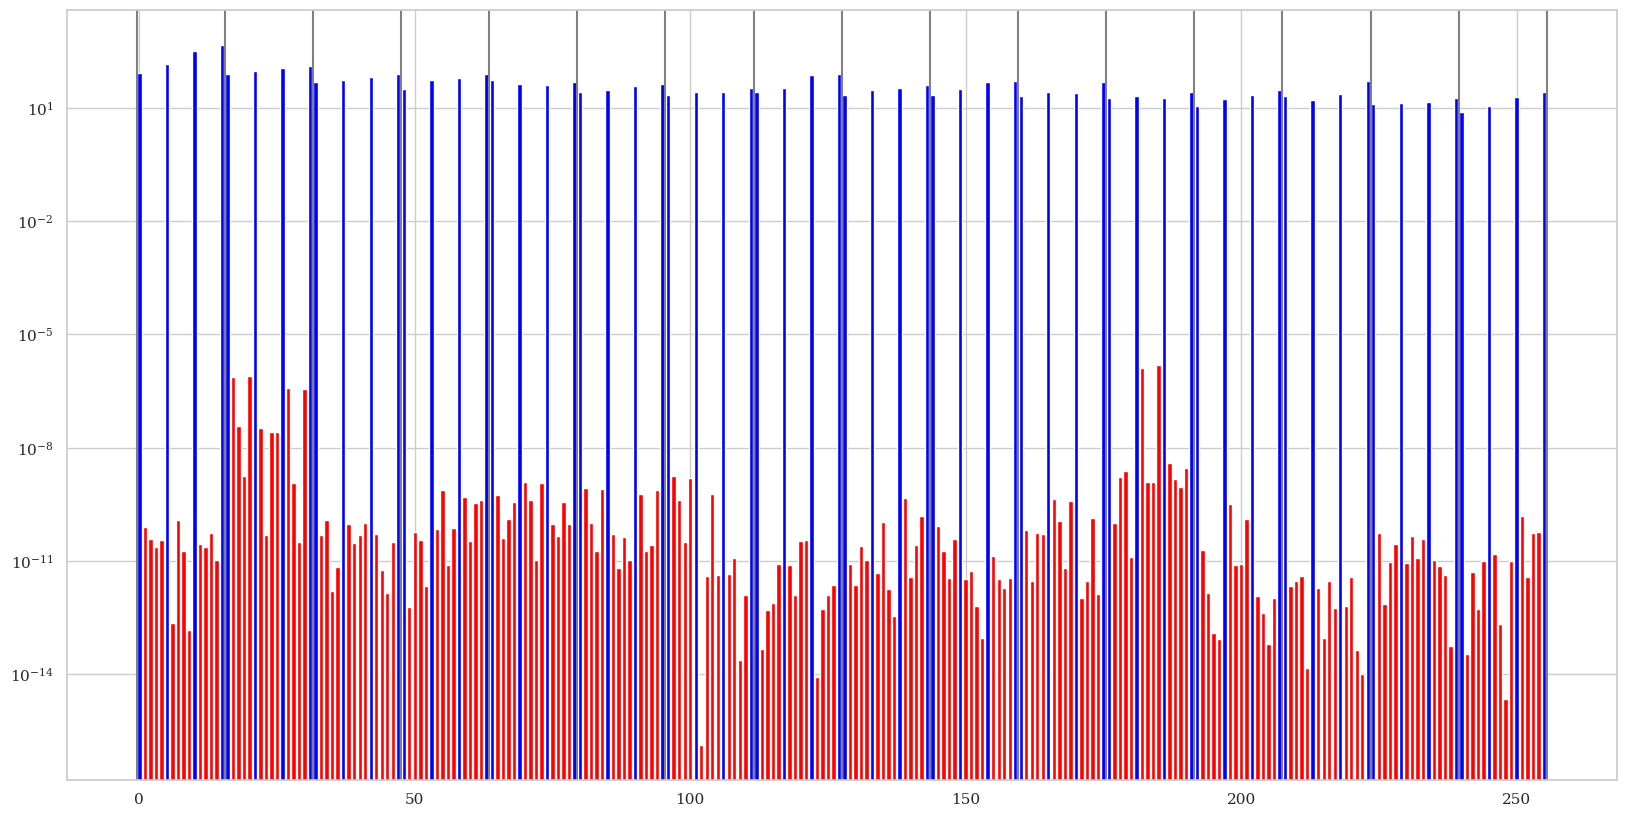

In [10]:
import scipy.stats
import seaborn as sns
import math
import numpy as np

samples = []
for c in bttda.blocks_[0].classes_:
    samples.append(tl.to_numpy(Xt)[y==c])
F,p = scipy.stats.f_oneway(*samples, axis=0)
F = F.flatten()
p = p.flatten()
p = np.nan_to_num(p, nan=1)

alpha=0.05
sig_idc = p < alpha

fig, ax = plt.subplots(1,1, figsize=(20,10))
ax.bar(np.arange(len(F))[sig_idc],F[sig_idc], color='blue')
ax.bar(np.arange(len(F))[~sig_idc],F[~sig_idc], color='red')
ax.set_yscale('log')
n_params=0
ax.axvline(n_params-.5, color='grey')
for b in bttda.blocks_:
    n_params+=math.prod(b.rank_)
    ax.axvline(n_params-.5, color='grey')


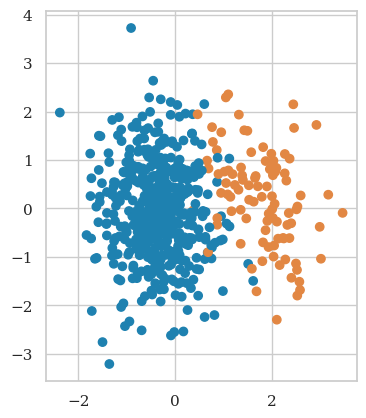

In [11]:
from sklearn.manifold import TSNE
import math
from sklearn.decomposition import PCA
import re, seaborn as sns
import numpy as np
from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import ListedColormap

if Xt.shape[-1] > 1:
    n_components = 2
    decomp  = PCA(n_components=n_components, whiten=True)
    Xt_viz = decomp.fit_transform(tl.to_numpy(Xt[:,sig_idc]))
    
    cmap = {'Target': '#e28743', 'NonTarget': '#1e81b0'}
    c = np.vectorize(cmap.get)(y)    
    fig, ax = plt.subplots(1,1)
    ax.scatter(Xt_viz[:,0], Xt_viz[:,1], c=c)
    ax.set_aspect('equal')
